<a href="https://colab.research.google.com/github/RamcharanChandragiri/MACHINE-LEARNING/blob/main/ML_Lab_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random Forest Implementation: Using Random Forest from libraries and
comparing results with AdaBoost and single Decision Tree

Kaggle Dataset Link: https://www.kaggle.com/competitions/titanic?

Tasks:
1. Load train.csv and preprocess data:
Handle missing values (Age)
Encode categorical features (Sex, Embarked)
2. Train:
Decision Tree Classifier
AdaBoost Classifier
Random Forest Classifier
3. Evaluate all three models using:
Accuracy
Precision, Recall, F1-score
4. Plot confusion matrices for all models.
5. Identify which ensemble method performs best.


In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
df = pd.read_csv("titanic_train.csv")
df.head()
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
X = df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y = df['Survived']

/tmp/ipykernel_148/4264195508.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_148/4264195508.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [12]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("Decision Tree Report")
print(classification_report(y_test, dt_pred))

print("AdaBoost Report")
print(classification_report(y_test, ada_pred))

print("Random Forest Report")
print(classification_report(y_test, rf_pred))

Decision Tree Accuracy: 0.7821229050279329
AdaBoost Accuracy: 0.7932960893854749
Random Forest Accuracy: 0.8212290502793296
Decision Tree Report
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179

AdaBoost Report
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179

Random Forest Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74



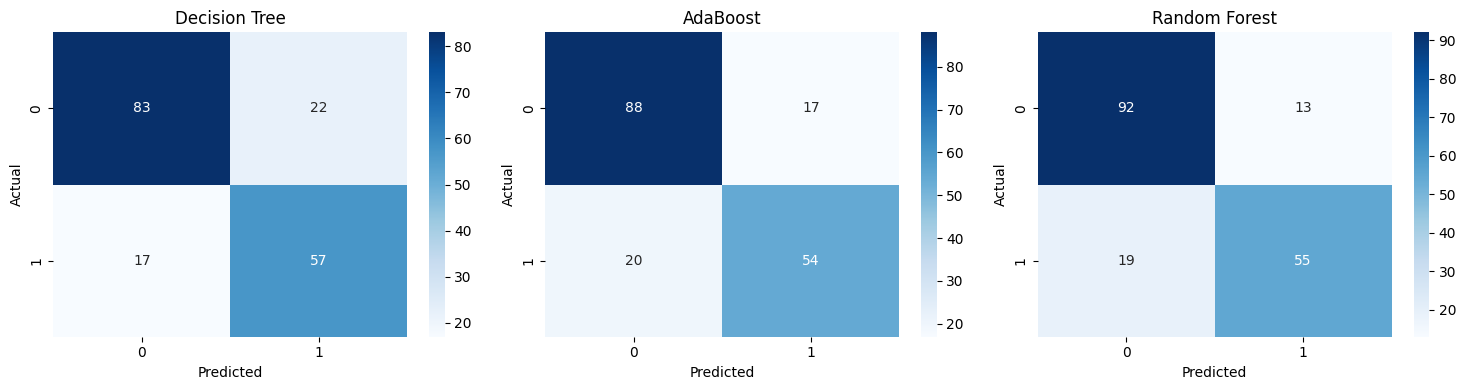

In [16]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

models = [dt_pred, ada_pred, rf_pred]
titles = ["Decision Tree", "AdaBoost", "Random Forest"]

for i in range(3):
    cm = confusion_matrix(y_test, models[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Random Forest Implementation: Using Random Forest from libraries and
comparing results with AdaBoost and single Decision Tree

Kaggle Dataset Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?

Tasks:
1. Load dataset and encode target variable (M → 1, B → 0).
2. Split dataset into training and testing sets (80/20).
3. Train:
Decision Tree
AdaBoost
Random Forest
4. Compare models using:
Accuracy
ROC-AUC Score
5. Conclude which algorithm provides the most reliable diagnosis.


In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

In [18]:
df = pd.read_csv("data.csv")
df.head()
df = df.drop(['id', 'Unnamed: 32'], axis=1)
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)
ada_prob = ada.predict_proba(X_test)[:,1]

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [22]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("---------------------------------------------------------")
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, dt_prob))
print("AdaBoost ROC-AUC:", roc_auc_score(y_test, ada_prob))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

Decision Tree Accuracy: 0.9473684210526315
AdaBoost Accuracy: 0.9736842105263158
Random Forest Accuracy: 0.9649122807017544
---------------------------------------------------------
Decision Tree ROC-AUC: 0.9439895185063871
AdaBoost ROC-AUC: 0.9944317065181788
Random Forest ROC-AUC: 0.9952505732066819


 Random Forest Implementation: Using Random Forest from libraries and
comparing results with AdaBoost and single Decision Tree

Kaggle Dataset Link: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data?

Tasks:
1. Load and preprocess dataset (handle missing values if any).
2. Train and test:
Decision Tree classifier
AdaBoost classifier
Random Forest classifier
3. Evaluate each model using:
Accuracy
F1-score
4. Plot Feature Importance from Random Forest.
5. Explain how ensemble methods improve performance over a single tree.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

In [25]:
df = pd.read_csv("heart_disease_uci.csv")
df.head()
print(df.isnull().sum())

# Rename 'num' to 'target' as per the problem description
df.rename(columns={'num': 'target'}, inplace=True)

# Drop 'id' and 'dataset' as they are likely identifiers/redundant
df = df.drop(['id', 'dataset'], axis=1)

# Identify numeric columns for median imputation
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Identify categorical columns for mode imputation
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# Convert categorical columns to numerical using one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop('target', axis=1)
y = df['target']

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


/tmp/ipykernel_148/1946947722.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_148/1946947722.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [29]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("Decision Tree F1 Score:", f1_score(y_test, dt_pred, average='weighted'))
print("AdaBoost F1 Score:", f1_score(y_test, ada_pred, average='weighted'))
print("Random Forest F1 Score:", f1_score(y_test, rf_pred, average='weighted'))

Decision Tree Accuracy: 0.47282608695652173
AdaBoost Accuracy: 0.532608695652174
Random Forest Accuracy: 0.5434782608695652
Decision Tree F1 Score: 0.4617997328934004
AdaBoost F1 Score: 0.47517923969142695
Random Forest F1 Score: 0.5039707256306446


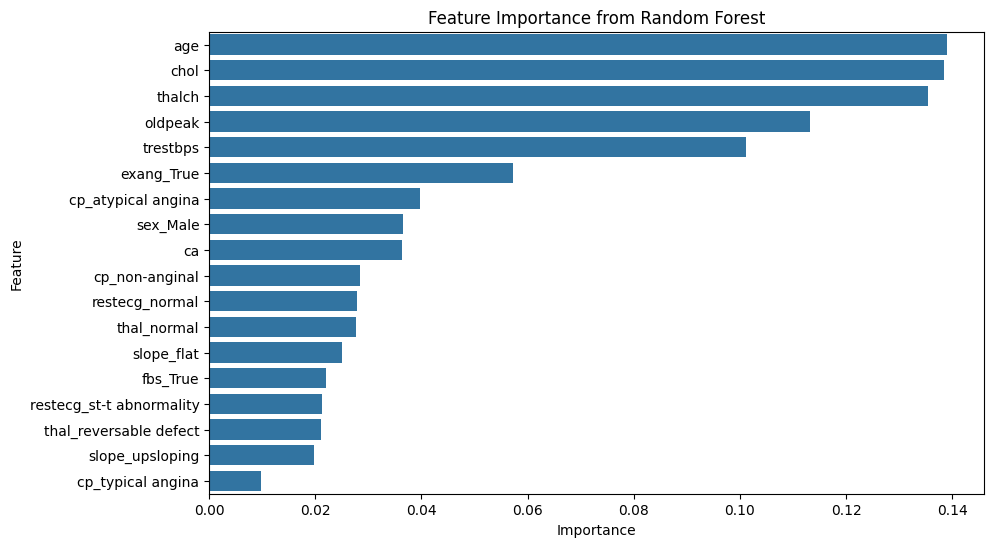

In [30]:
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance from Random Forest")
plt.show()

Random Forest Implementation: Using Random Forest from libraries and
comparing results with AdaBoost and single Decision Tree
Kaggle Dataset Link: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

Tasks:
1. Load dataset and preprocess categorical features.
2. Train:
Decision Tree
AdaBoost
Random Forest
3. Evaluate models using:
Accuracy
Confusion Matrix
4. Compare training vs testing accuracy for all models.
5. Discuss bias–variance tradeoff among the three models.

In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")
df.head()
print(df.isnull().sum())
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
le = LabelEncoder()

categorical_cols = [
    'Gender','Married','Dependents',
    'Education','Self_Employed',
    'Property_Area','Loan_Status'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop(['Loan_ID','Loan_Status'], axis=1)
y = df['Loan_Status']

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


/tmp/ipykernel_148/482468478.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_148/482468478.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [35]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_train_pred = dt.predict(X_train)
dt_test_pred = dt.predict(X_test)

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

ada_train_pred = ada.predict(X_train)
ada_test_pred = ada.predict(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

In [36]:
print("Decision Tree Train Accuracy:", accuracy_score(y_train, dt_train_pred))
print("Decision Tree Test Accuracy:", accuracy_score(y_test, dt_test_pred))

print("AdaBoost Train Accuracy:", accuracy_score(y_train, ada_train_pred))
print("AdaBoost Test Accuracy:", accuracy_score(y_test, ada_test_pred))

print("Random Forest Train Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Random Forest Test Accuracy:", accuracy_score(y_test, rf_test_pred))

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.6910569105691057
AdaBoost Train Accuracy: 0.8289205702647657
AdaBoost Test Accuracy: 0.7886178861788617
Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.7560975609756098


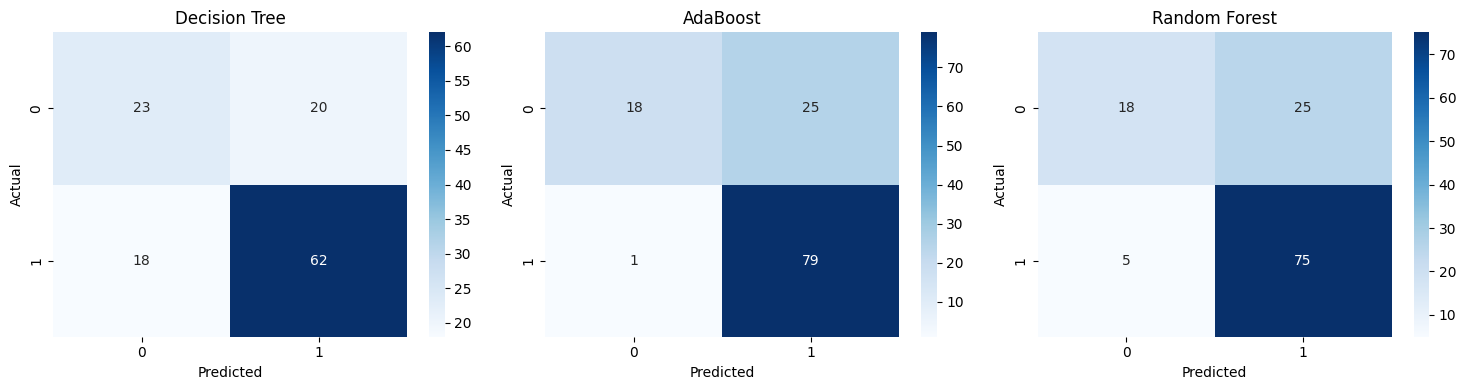

In [38]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

models = [dt_test_pred, ada_test_pred, rf_test_pred]
titles = ["Decision Tree", "AdaBoost", "Random Forest"]

for i in range(3):
    cm = confusion_matrix(y_test, models[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

 Random Forest Implementation: Using Random Forest from libraries and
comparing results with AdaBoost and single Decision Tree

Kaggle Dataset Link:
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset?

Tasks:
1. Load dataset and preprocess features.
2. Train baseline Decision Tree model.
3. Train AdaBoost and Random Forest models.
4. For Random Forest, vary:
n_estimators (50, 100, 200)
max_depth
5. Compare all models using:
Accuracy
Precision, Recall
ROC-AUC
6. Identify the best-performing model and justify

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

from sklearn.preprocessing import StandardScaler

In [40]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.head()
df = df.drop('ID', axis=1)
X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [42]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)
ada_prob = ada.predict_proba(X_test)[:,1]

In [43]:
rf50 = RandomForestClassifier(n_estimators=50, random_state=42)
rf50.fit(X_train, y_train)

rf50_pred = rf50.predict(X_test)
rf50_prob = rf50.predict_proba(X_test)[:,1]

rf100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf100.fit(X_train, y_train)

rf100_pred = rf100.predict(X_test)
rf100_prob = rf100.predict_proba(X_test)[:,1]

rf200 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf200.fit(X_train, y_train)

rf200_pred = rf200.predict(X_test)
rf200_prob = rf200.predict_proba(X_test)[:,1]

In [44]:
def evaluate_model(y_test, pred, prob):

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    roc = roc_auc_score(y_test, prob)

    return acc, precision, recall, roc

In [45]:
models = {
    "Decision Tree": (dt_pred, dt_prob),
    "AdaBoost": (ada_pred, ada_prob),
    "RF (50 trees)": (rf50_pred, rf50_prob),
    "RF (100 trees)": (rf100_pred, rf100_prob),
    "RF (200 trees depth10)": (rf200_pred, rf200_prob)
}

for name, (pred, prob) in models.items():
    acc, prec, rec, roc = evaluate_model(y_test, pred, prob)

    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("ROC-AUC:", roc)
    print()

Decision Tree
Accuracy: 0.726
Precision: 0.3813620071684588
Recall: 0.4051789794364052
ROC-AUC: 0.6105833721019605

AdaBoost
Accuracy: 0.8181666666666667
Precision: 0.6801948051948052
Recall: 0.31911652703731913
ROC-AUC: 0.774777133881841

RF (50 trees)
Accuracy: 0.816
Precision: 0.6406460296096904
Recall: 0.3625285605483625
ROC-AUC: 0.7541006049530787

RF (100 trees)
Accuracy: 0.816
Precision: 0.6376811594202898
Recall: 0.3686214775323686
ROC-AUC: 0.7582379744268432

RF (200 trees depth10)
Accuracy: 0.8188333333333333
Precision: 0.6614285714285715
Recall: 0.3526275704493526
ROC-AUC: 0.7778574726061667

